In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics

from sklearn.preprocessing import LabelEncoder,StandardScaler,MinMaxScaler,RobustScaler,OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
import xgboost as xgb

import plotly as py
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot, plot
import plotly.express as px

from imblearn.over_sampling import KMeansSMOTE, SMOTE, ADASYN, BorderlineSMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, NearMiss, TomekLinks, EditedNearestNeighbours, RepeatedEditedNearestNeighbours
from imblearn.combine import SMOTEENN, SMOTETomek

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.model_selection import cross_val_score, cross_val_predict, cross_validate, StratifiedKFold, train_test_split, GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold, RepeatedKFold, RepeatedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.model_selection import permutation_test_score, StratifiedShuffleSplit

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import PowerTransformer

from sklearn.feature_selection import SelectKBest, SelectPercentile, SelectFromModel, RFE, RFECV
from sklearn.feature_selection import chi2, f_classif, mutual_info_classif
from sklearn.feature_selection import f_regression, mutual_info_regression

from collections import Counter

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.model_selection import (cross_validate, StratifiedKFold, train_test_split,GridSearchCV,
                                    HalvingGridSearchCV)

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.utils.class_weight import compute_class_weight

from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

print("Project has been created with this version of Pandas: " ,pd. __version__," And with this version of Numpy: ",np. __version__)

Project has been created with this version of Pandas:  2.2.2  And with this version of Numpy:  1.26.4


In [ ]:
df = pd.read_csv('../datasets/processed/heart_no_nans.csv')

In [3]:
df.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,HighCholesterol,HighBloodPressure,HadHeartAttack,...,RaceEthnicityCategory,AgeCategory,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past 2 years (1 year but less than 2 ye...,No,No,Yes,No,...,"White only, Non-Hispanic",Age 80 or older,1.60,78.02,30.47,No,No,No,No,No
1,Alabama,Female,Very good,0.0,0.0,Within past 2 years (1 year but less than 2 ye...,Yes,Yes,Yes,No,...,"White only, Non-Hispanic",Age 80 or older,1.45,59.87,28.56,No,No,Yes,Yes,No
2,Alabama,Female,Very good,2.0,0.0,Within past 5 years (2 years but less than 5 y...,Yes,No,No,No,...,"White only, Non-Hispanic",Age 75 to 79,1.68,77.11,27.44,No,Yes,Yes,Yes,No
3,Alabama,Female,Fair,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,No,Yes,No,...,"White only, Non-Hispanic",Age 75 to 79,1.73,77.11,25.85,Yes,No,No,Yes,No
4,Alabama,Female,Good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,Yes,Yes,No,...,"Black only, Non-Hispanic",Age 60 to 64,1.57,74.84,30.18,Yes,Yes,No,No,Yes


In [4]:
df.duplicated().sum()

196

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.duplicated().sum()

0

In [7]:
label_encoder = LabelEncoder()

label_columns = ['HighBloodPressure', 'LastCheckupTime', 'HadDiabetes']

for col in label_columns:
    df[col] = label_encoder.fit_transform(df[col])

In [8]:
df = pd.get_dummies(df, columns=['RaceEthnicityCategory', 'Sex'], dtype=int, drop_first=True)

In [9]:
ordinal_mapping = {
    'GeneralHealth': { "Excellent": 5, "Very good": 4, "Good": 3, "Fair": 2, "Poor": 1 },
    'SmokerStatus': { "Current smoker - now smokes every day": 4,
                     "Current smoker - now smokes some days": 3,
                     "Former smoker": 2,
                     "Never smoked": 1 },
    'ECigaretteUsage': { "Never used e-cigarettes in my entire life": 1,
                         "Use them every day": 4,
                         "Use them some days": 3,
                         "Not at all (right now)": 2 },
    'AgeCategory': { "Age 18 to 24": 1, "Age 25 to 29": 2, "Age 30 to 34": 3,
                    "Age 35 to 39": 4, "Age 40 to 44": 5, "Age 45 to 49": 6,
                    "Age 50 to 54": 7, "Age 55 to 59": 8, "Age 60 to 64": 9,
                    "Age 65 to 69": 10, "Age 70 to 74": 11, "Age 75 to 79": 12,
                    "Age 80 or older": 13 }
}

for col, mapping in ordinal_mapping.items():
    df[col] = df[col].map(mapping)

In [10]:
df.replace({'No': 0, 'Yes': 1}, inplace=True)

In [11]:
state_encoding = df.groupby('State')['HadHeartAttack'].mean().to_dict()
df['State'] = df['State'].map(state_encoding)

In [12]:
df.head()

,State,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,HighCholesterol,HighBloodPressure,HadHeartAttack,HadAngina,...,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,CovidPos,RaceEthnicityCategory_Hispanic,"RaceEthnicityCategory_Multiracial, Non-Hispanic","RaceEthnicityCategory_Other race only, Non-Hispanic","RaceEthnicityCategory_White only, Non-Hispanic",Sex_Male
0,0.061544,4,0.0,0.0,1,0,0,2,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0.061544,4,0.0,0.0,1,1,1,2,0,0,...,0,0,1,1,0,0,0,0,1,0
2,0.061544,4,2.0,0.0,2,1,0,0,0,0,...,0,1,1,1,0,0,0,0,1,0
3,0.061544,2,0.0,0.0,3,1,0,2,0,0,...,1,0,0,1,0,0,0,0,1,0
4,0.061544,3,2.0,3.0,3,1,1,2,0,0,...,1,1,0,0,1,0,0,0,0,0


In [13]:
df.columns

Index(['State', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays',
       'LastCheckupTime', 'PhysicalActivities', 'HighCholesterol',
       'HighBloodPressure', 'HadHeartAttack', 'HadAngina', 'HadStroke',
       'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder',
       'HadKidneyDisease', 'HadArthritis', 'HadDiabetes',
       'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
       'ECigaretteUsage', 'AgeCategory', 'HeightInMeters', 'WeightInKilograms',
       'BMI', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'CovidPos', 'RaceEthnicityCategory_Hispanic',
       'RaceEthnicityCategory_Multiracial, Non-Hispanic',
       'RaceEthnicityCategory_Other race only, Non-Hispanic',
       'RaceEthnicityCategory_White only, Non-Hispanic', 'Sex_Male'],
      dtype='object')

In [14]:
# Prepare the data
X = df.drop('HadHeartAttack', axis=1)
y = df['HadHeartAttack']

In [15]:
X = sm.add_constant(X)

In [16]:
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Menampilkan hasil VIF
vif_data

,Variable,VIF
0,const,4799.970043
1,State,1.041212
2,GeneralHealth,1.722273
3,PhysicalHealthDays,1.599703
4,MentalHealthDays,1.477340
5,LastCheckupTime,1.095698
6,PhysicalActivities,1.199682
7,HighCholesterol,1.171805
8,HighBloodPressure,1.303678
9,HadAngina,1.117766


In [17]:
X = X.drop('const', axis=1)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

In [19]:
column_names = X_train.columns

In [20]:
# Menstandarisasi fitur menggunakan StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# Pilih kolom yang akan diproses dengan PCA
columns_to_pca = df[['HeightInMeters', 'WeightInKilograms', 'BMI']]

# Terapkan PCA untuk mereduksi dimensi menjadi 1 komponen utama
pca = PCA(n_components=1)
df['BMI_PCA'] = pca.fit_transform(columns_to_pca)

# Hapus kolom asli yang sudah digantikan oleh PCA
df.drop(['HeightInMeters', 'WeightInKilograms', 'BMI'], axis=1, inplace=True)

# Menampilkan DataFrame setelah PCA diterapkan
df

,State,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,HighCholesterol,HighBloodPressure,HadHeartAttack,HadAngina,...,HIVTesting,FluVaxLast12,PneumoVaxEver,CovidPos,RaceEthnicityCategory_Hispanic,"RaceEthnicityCategory_Multiracial, Non-Hispanic","RaceEthnicityCategory_Other race only, Non-Hispanic","RaceEthnicityCategory_White only, Non-Hispanic",Sex_Male,BMI_PCA
0,0.061544,4,0.0,0.0,1,0,0,2,0,0,...,0,0,0,0,0,0,0,1,0,-4.850158
1,0.061544,4,0.0,0.0,1,1,1,2,0,0,...,0,1,1,0,0,0,0,1,0,-22.875332
2,0.061544,4,2.0,0.0,2,1,0,0,0,0,...,1,1,1,0,0,0,0,1,0,-6.514145
3,0.061544,2,0.0,0.0,3,1,0,2,0,0,...,0,0,1,0,0,0,0,1,0,-6.926099
4,0.061544,3,2.0,3.0,3,1,1,2,0,0,...,1,0,0,1,0,0,0,0,0,-7.996726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257692,0.030075,3,0.0,0.0,3,1,1,2,0,0,...,1,0,0,0,0,0,0,0,0,-9.868682
257693,0.030075,4,0.0,0.0,1,0,0,2,0,0,...,1,0,1,0,0,0,0,0,1,-18.555761
257694,0.030075,4,0.0,0.0,3,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,-15.917022
257695,0.030075,4,10.0,0.0,3,1,1,0,0,0,...,1,1,0,0,1,0,0,0,0,14.127806


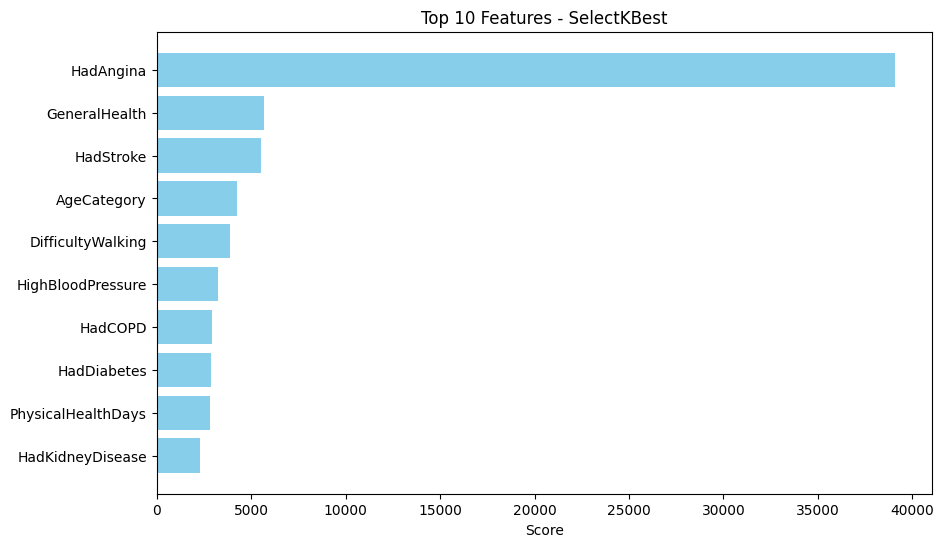

In [22]:
# Fit SelectKBest
selector = SelectKBest(score_func=f_classif, k=10)  # Select top 5 features
X_train_selected = selector.fit_transform(X_train_scaled, y_train)

# Get the feature scores
feature_scores = selector.scores_

# Get the feature names (if your columns are named)
feature_names = X_train.columns
selected_features = X.columns[selector.get_support()]

# Create a DataFrame to store feature names and their corresponding scores
feature_score_df = pd.DataFrame({
    'Feature': feature_names,
    'Score': feature_scores
})

# Sort the scores in descending order
feature_score_df = feature_score_df.sort_values(by='Score', ascending=False)

# Select the top 10 features
top_5_features = feature_score_df.head(10)

# Plot the top 10 feature scores
plt.figure(figsize=(10, 6))
plt.barh(top_5_features['Feature'], top_5_features['Score'], color='skyblue')
plt.xlabel('Score')
plt.title('Top 10 Features - SelectKBest')
plt.gca().invert_yaxis()  # Invert y-axis to display the highest score at the top
plt.show()

In [23]:
# Memilih kolom-kolom fitur yang dipilih
selected_columns = X.columns[selector.get_support()]

# Menampilkan fitur terpilih
print("Selected Features:", selected_columns)

Selected Features: Index(['GeneralHealth', 'PhysicalHealthDays', 'HighBloodPressure', 'HadAngina',
       'HadStroke', 'HadCOPD', 'HadKidneyDisease', 'HadDiabetes',
       'DifficultyWalking', 'AgeCategory'],
      dtype='object')


In [24]:
# 3. **Apply SMOTE for Imbalanced Classes**
smote = SMOTE(sampling_strategy='auto', random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_selected, y_train)

Accuracy: 0.8294498812773229
Precision: 0.2107110507246377
Recall: 0.7225781401669579
F1 Score: 0.3262765724304186
ROC AUC: 0.7792531771737996
              precision    recall  f1-score   support

           0       0.98      0.84      0.90     84975
           1       0.21      0.72      0.33      5151

    accuracy                           0.83     90126
   macro avg       0.60      0.78      0.61     90126
weighted avg       0.94      0.83      0.87     90126



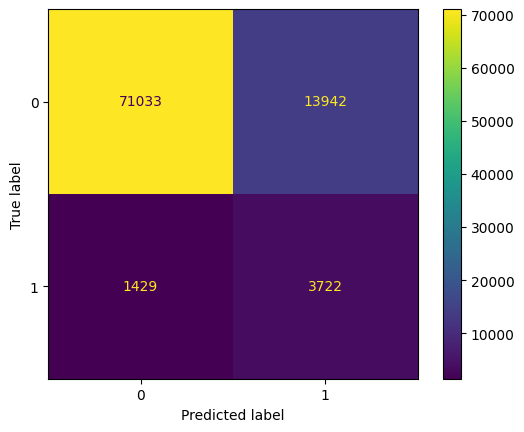

In [25]:
# Bangun model Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)

# Latih model pada data yang sudah di-resample
logreg.fit(X_train_smote, y_train_smote)

# Evaluasi model
y_pred = logreg.predict(X_test_scaled[:, selector.get_support()])  # Gunakan fitur yang dipilih

# Evaluasi hasil menggunakan metrik
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

# Tampilkan confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)  # Corrected argument name
conf_matrix_display.plot()

# Tampilkan classification report
print(classification_report(y_test, y_pred))

In [26]:
import pickle

# Simpan model ke file
with open('logreg_model.pkl', 'wb') as f:
    pickle.dump(logreg, f)



---



In [243]:
# Shift data untuk memastikan tidak ada nilai negatif
X_train_scaled_positive = X_train_scaled - X_train_scaled.min(axis=0)
X_test_scaled_positive = X_test_scaled - X_test_scaled.min(axis=0)

# Apply SelectKBest with Chi-Squared
selector = SelectKBest(score_func=chi2, k=10)  # Pilih 10 fitur terbaik
X_train_selected = selector.fit_transform(X_train_scaled_positive, y_train)
X_test_selected = selector.transform(X_test_scaled_positive)

In [244]:
# 5. **Apply SMOTE for Imbalanced Classes**
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_selected, y_train)

In [245]:
# 6. **Build Logistic Regression Model**
logreg = LogisticRegression(max_iter=1000, random_state=42)

In [246]:
# 7. **Cross-validation to maximize recall score**
# Gunakan Stratified KFold untuk memastikan distribusi target yang seimbang
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cross_val_scores = cross_val_score(logreg, X_train_smote, y_train_smote, cv=cv, scoring='recall')
print(f"Cross-validation Recall Scores: {cross_val_scores}")
print(f"Mean Cross-validation Recall Score: {cross_val_scores.mean():.4f}")

Cross-validation Recall Scores: [0.68469523 0.68284964 0.68307118 0.68064434 0.68884107]
Mean Cross-validation Recall Score: 0.6840


In [247]:
# 8. **Train the model using the entire training set**
logreg.fit(X_train_smote, y_train_smote)

# 9. **Evaluate the Model**
y_pred = logreg.predict(X_test_selected)
y_pred_prob = logreg.predict_proba(X_test_selected)[:, 1]

# 10. **Evaluation Metrics**
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

Accuracy: 0.8589974036349112
Precision: 0.23964721284365742
Recall: 0.6752086973403223
F1 Score: 0.35374288039056145
ROC AUC: 0.833122187147327


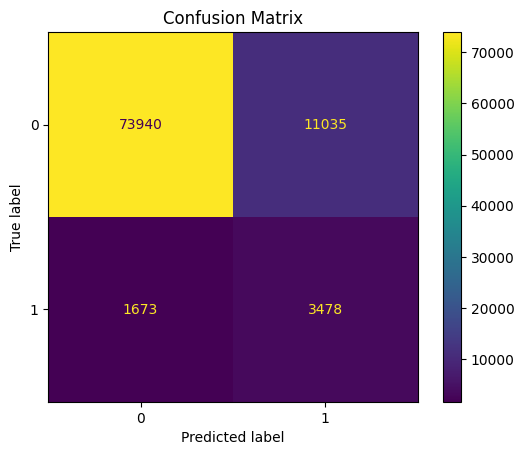

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.87      0.92     84975
           1       0.24      0.68      0.35      5151

    accuracy                           0.86     90126
   macro avg       0.61      0.77      0.64     90126
weighted avg       0.94      0.86      0.89     90126



In [248]:
# 11. **Confusion Matrix**
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
conf_matrix_display.plot()
plt.title('Confusion Matrix')
plt.show()

# 12. **Classification Report**
print("Classification Report:")
print(classification_report(y_test, y_pred))



---



In [249]:
# 1. **Feature Selection with RFE**
logreg = LogisticRegression(max_iter=1000, random_state=42)


In [250]:
# Gunakan RFE untuk memilih fitur terbaik
rfe = RFE(estimator=logreg, n_features_to_select=10)
X_train_selected_rfe = rfe.fit_transform(X_train_scaled, y_train)
X_test_selected_rfe = rfe.transform(X_test_scaled)

# Dapatkan fitur yang terpilih
selected_features_rfe = column_names[rfe.support_]
print("Selected Features using RFE:", selected_features_rfe)

Selected Features using RFE: Index(['GeneralHealth', 'HighCholesterol', 'HighBloodPressure', 'HadAngina',
       'HadStroke', 'HadDiabetes', 'SmokerStatus', 'AgeCategory',
       'AlcoholDrinkers', 'Sex_Male'],
      dtype='object')


In [251]:
# 2. **Apply SMOTE for Imbalanced Classes**
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_selected_rfe, y_train)

# 3. **Cross-validation with Stratified KFold**
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cross_val_scores = cross_val_score(logreg, X_train_smote, y_train_smote, cv=cv, scoring='recall')

# Print cross-validation results
print(f"Cross-validation recall scores: {cross_val_scores}")
print(f"Mean recall score: {cross_val_scores.mean()}")

Cross-validation recall scores: [0.75042724 0.74902681 0.74586195 0.74881322 0.75191468]
Mean recall score: 0.7492087783325226


In [252]:
# 4. **Train Logistic Regression on the Entire Resampled Dataset**
logreg.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

Accuracy: 0.827574728713135
Precision: 0.21267769235024062
Recall: 0.7464569986410405
F1 Score: 0.3310374515712441
ROC AUC: 0.8742596098559028


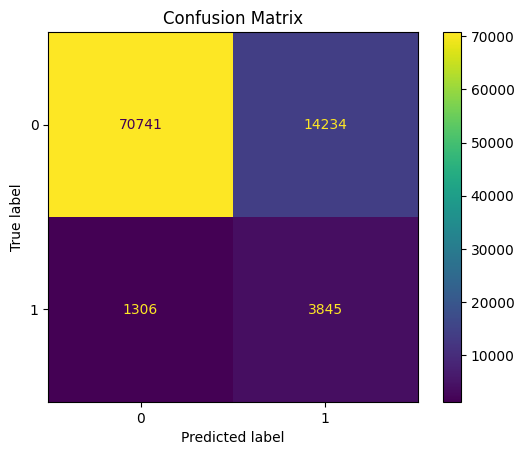

              precision    recall  f1-score   support

           0       0.98      0.83      0.90     84975
           1       0.21      0.75      0.33      5151

    accuracy                           0.83     90126
   macro avg       0.60      0.79      0.62     90126
weighted avg       0.94      0.83      0.87     90126



In [253]:
# 5. **Evaluate the Model**
y_pred = logreg.predict(X_test_selected_rfe)
y_pred_prob = logreg.predict_proba(X_test_selected_rfe)[:, 1]

# Evaluasi hasil menggunakan metrik
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

# Tampilkan confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
conf_matrix_display.plot()
plt.title('Confusion Matrix')
plt.show()

# Tampilkan classification report
print(classification_report(y_test, y_pred))



---



In [254]:
# **Hyperparameter Tuning with GridSearchCV**
param_grid = {
    'C': [0.0001 ,0.001, 0.01, 0.1],  # Regularization strength
    'solver': ['liblinear', 'saga'],  # Solvers
    'penalty': ['l2', 'elasticnet']  # Regularization methods
}

grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='recall')
grid_search.fit(X_train_smote, y_train_smote)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.0001, 0.001, 0.01, 0.1],
                         'penalty': ['l2', 'elasticnet'],
                         'solver': ['liblinear', 'saga']},
             scoring='recall')

In [255]:
# **Train Logistic Regression with Best Parameters**
best_model = grid_search.best_estimator_
best_model.fit(X_train_smote, y_train_smote)

LogisticRegression(C=0.0001, solver='liblinear')

In [256]:
# **Evaluate the Model**
X_test_selected = selector.transform(X_test_scaled)  # Terapkan seleksi fitur yang sama pada X_test
y_pred = best_model.predict(X_test_selected)  # Gunakan best_model dari GridSearchCV untuk prediksi
y_pred_prob = best_model.predict_proba(X_test_selected)[:, 1]

In [257]:
# Best parameters from GridSearchCV
print(f"Best Hyperparameters: {grid_search.best_params_}")

# Accuracy, Precision, Recall, F1-Score, ROC AUC
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Best Hyperparameters: {'C': 0.0001, 'penalty': 'l2', 'solver': 'liblinear'}
Accuracy: 0.8216
Precision: 0.1524
Recall: 0.4648
F1 Score: 0.2295
ROC AUC: 0.7519


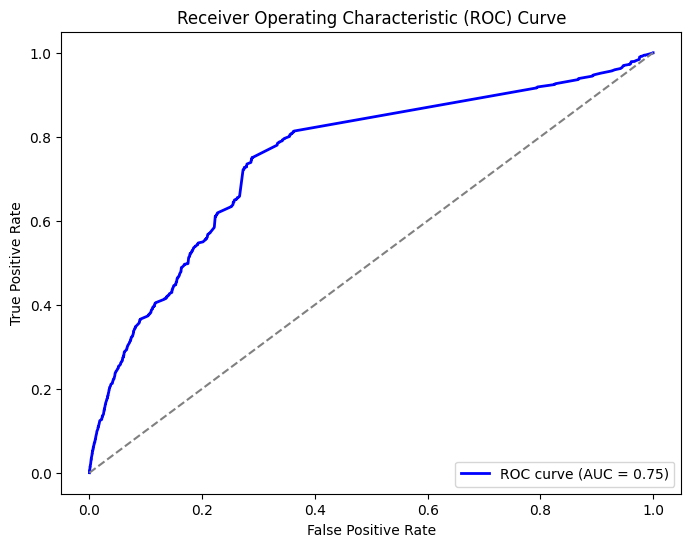

In [258]:
# **Plot ROC Curve**
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [259]:
# **Cross-Validation**
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cross_val_scores = cross_val_score(best_model, X_train_smote, y_train_smote, cv=cv, scoring='recall')
print(f"Cross-validation Scores: {cross_val_scores}")
print(f"Mean Cross-validation Score: {cross_val_scores.mean():.4f}")

Cross-validation Scores: [0.76976391 0.76618033 0.76339526 0.76916261 0.77210583]
Mean Cross-validation Score: 0.7681


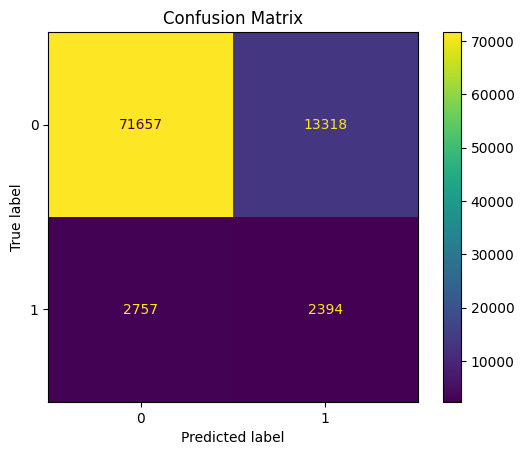

In [260]:
# **Confusion Matrix**
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix_display = ConfusionMatrixDisplay(conf_matrix)  # Perbaikan di sini
conf_matrix_display.plot()
plt.title('Confusion Matrix')
plt.show()



---



In [ ]:
# 4. **Hyperparameter Tuning with GridSearchCV for Random Forest**
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4],    # Minimum number of samples required to be at a leaf node
    'random_state': [42]
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='recall')
grid_search.fit(X_train_smote, y_train_smote)

# Best parameters from GridSearchCV
print(f"Best Hyperparameters: {grid_search.best_params_}")

In [ ]:
# 5. **Train Random Forest with Best Parameters**
best_model = grid_search.best_estimator_
best_model.fit(X_train_smote, y_train_smote)

In [ ]:
# 6. **Evaluate the Model**
y_pred = best_model.predict(X_test_selected)
y_pred_prob = best_model.predict_proba(X_test_selected)[:, 1]

# Accuracy, Precision, Recall, F1-Score, ROC AUC
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

In [ ]:
# 7. **Plot ROC Curve**
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# 8. **Cross-Validation**
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cross_val_scores = cross_val_score(best_model, X_train_smote, y_train_smote, cv=cv, scoring='recall')
print(f"Cross-validation Scores: {cross_val_scores}")
print(f"Mean Cross-validation Score: {cross_val_scores.mean():.4f}")

In [ ]:
# 9. **Confusion Matrix**
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
conf_matrix_display.plot()
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# 10. **Classification Report**
classification_report(y_test, y_pred)



---



In [266]:
# Apply ENN to the training set
enn = EditedNearestNeighbours(n_neighbors=3)
X_train_resampled_enn, y_train_resampled_enn = enn.fit_resample(X_train_scaled, y_train)

In [267]:
# Apply ENN to the training set
enn = EditedNearestNeighbours(n_neighbors=3)
X_train_resampled_enn, y_train_resampled_enn = enn.fit_resample(X_train_scaled, y_train)

# Compute class weights for handling class imbalance
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train_resampled_enn
)

In [286]:
# Define Random Forest Classifier
rf = RandomForestClassifier(random_state=42, class_weight={0: weights[0]*1.5, 1: weights[1]})

# Apply Hyperparameter Tuning with GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Perform GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search.fit(X_train_resampled_enn, y_train_resampled_enn)

# Best parameters from GridSearchCV
print(f"Best Hyperparameters: {grid_search.best_params_}")

KeyboardInterrupt: 

In [ ]:
# Train the model with the best parameters
best_rf_model = grid_search.best_estimator_
best_rf_model.fit(X_train_resampled_enn, y_train_resampled_enn)

In [ ]:
# Feature Importance based on Random Forest
feature_importances = best_rf_model.feature_importances_

# Sort the feature importances
indices = np.argsort(feature_importances)[::-1]
top_features = X_train_scaled.columns[indices]

# Visualize the top features
plt.figure(figsize=(10, 6))
plt.barh(top_features[:10], feature_importances[indices][:10], color='skyblue')
plt.xlabel('Importance')
plt.title('Top 10 Features based on Random Forest')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# **Evaluate the model on X_test (without ENN)**
X_test_selected = X_test_scaled.iloc[:, indices]  # Select features based on importance
y_pred = best_rf_model.predict(X_test_selected)
y_pred_prob = best_rf_model.predict_proba(X_test_selected)[:, 1]

# Metrics Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")

# **Cross-validation** for better generalization
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cross_val_scores = cross_val_score(best_rf_model, X_train_resampled_enn, y_train_resampled_enn, cv=cv, scoring='recall')
print(f"Cross-validation Scores: {cross_val_scores}")
print(f"Mean Cross-validation Score: {cross_val_scores.mean():.4f}")

In [ ]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix_display = ConfusionMatrixDisplay(conf_matrix=conf_matrix)
conf_matrix_display.plot()
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Classification Report
classification_report(y_test, y_pred)



---



In [268]:
# **Step 3: Hyperparameter Tuning with GridSearchCV**
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],  # Regularization rate
    'max_depth': [3, 5, 7],  # Depth of trees
    'n_estimators': [100, 200, 300],  # Number of trees
    'subsample': [0.8, 1.0],  # Subsample ratio
    'colsample_bytree': [0.8, 1.0]  # Feature sampling ratio
}

# Set the XGBoost model with class_weight
xgb_model = xgb.XGBClassifier(
    random_state=42,
    scale_pos_weight=weights[1] / weights[0],  # Adjust scale for imbalanced data
    objective='binary:logistic'
)

grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search.fit(X_train_resampled_enn, y_train_resampled_enn)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='recall')

In [269]:
# **Step 4: Train with Best Parameters**
best_model = grid_search.best_estimator_
best_model.fit(X_train_resampled_enn, y_train_resampled_enn)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [270]:
# **Step 5: Evaluate Model**
# Predict using the best model
y_pred = best_model.predict(X_test_scaled)
y_pred_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate results using metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Print the evaluation results
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Best Hyperparameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Accuracy: 0.8104
Precision: 0.2003
Recall: 0.7744
F1 Score: 0.3183
ROC AUC: 0.8792


In [271]:
# **Step 6: Cross-Validation**
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cross_val_scores = cross_val_score(best_model, X_train_resampled_enn, y_train_resampled_enn, cv=cv, scoring='recall')
print(f"Cross-validation Scores: {cross_val_scores}")
print(f"Mean Cross-validation Score: {cross_val_scores.mean():.4f}")

Cross-validation Scores: [0.77996803 0.77902023 0.78966986 0.77996803 0.7682472 ]
Mean Cross-validation Score: 0.7794


In [282]:
# Mengambil nama kolom dari DataFrame
feature_names = X_train.columns  # Pastikan X_train adalah DataFrame dengan nama fitur yang sesuai

# Langkah 1: Melatih model XGBoost (pastikan Anda sudah melatih model sebelumnya)
dtrain = xgb.DMatrix(X_train, label=y_train)  # Membuat DMatrix dengan X_train dan y_train
params = {'objective': 'reg:squarederror', 'eval_metric': 'rmse'}
best_model = xgb.train(params, dtrain, num_boost_round=100)

# Langkah 2: Mendapatkan feature importance berdasarkan 'weight' dan menambahkan nama kolom ke dalam dataframe
feature_importance = best_model.get_score(importance_type='weight')

# Mengonversi feature importance ke DataFrame
importance_df = pd.DataFrame(list(feature_importance.items()), columns=['Feature', 'Importance'])

# Menambahkan nama fitur dari X_train
importance_df['Feature'] = importance_df['Feature'].apply(lambda x: feature_names[int(x[1:])] if x.startswith('f') else x)

# Menampilkan hanya 10 fitur dengan importance tertinggi
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

# Visualisasi dengan Plotly (bar chart)
fig = px.bar(
    importance_df,
    x='Importance',
    y='Feature',
    title="Top 10 Feature Importance using XGBoost",
    labels={'Importance': 'Feature Importance', 'Feature': 'Feature'},
    orientation='h'  # Menampilkan horizontal bar chart
)

# Tampilkan plot interaktif
fig.show()

In [285]:
# Mengambil nama kolom dari DataFrame
feature_names = X_train.columns  # Pastikan X_train adalah DataFrame dengan nama fitur yang sesuai

# Langkah 2: Mendapatkan feature importance berdasarkan 'weight' dan menambahkan nama kolom ke dalam dataframe
feature_importance = best_model.get_score(importance_type='weight')

# Mengonversi feature importance ke DataFrame
importance_df = pd.DataFrame(list(feature_importance.items()), columns=['Feature', 'Importance'])

# Menambahkan nama fitur dari X_train
importance_df['Feature'] = importance_df['Feature'].apply(lambda x: feature_names[int(x[1:])] if x.startswith('f') else x)

# Menampilkan feature importance yang sudah terurut
importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df

,Feature,Importance
0,State,618.0
28,BMI,528.0
27,WeightInKilograms,473.0
8,HadAngina,423.0
25,AgeCategory,390.0
26,HeightInMeters,344.0
2,PhysicalHealthDays,326.0
1,GeneralHealth,268.0
9,HadStroke,204.0
3,MentalHealthDays,181.0


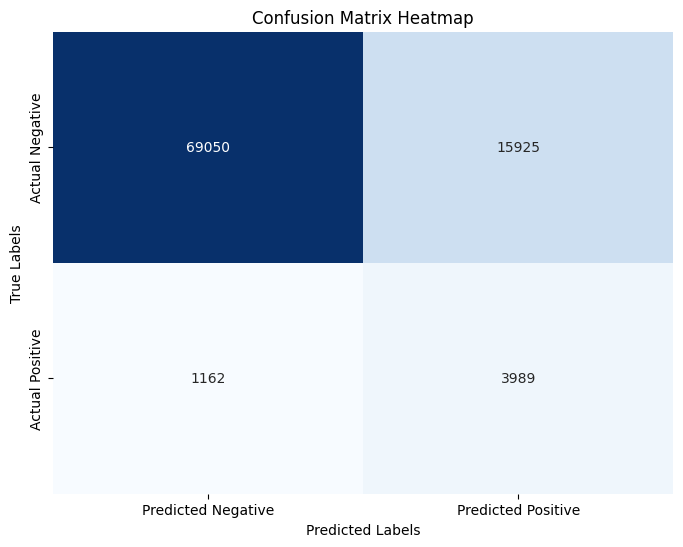

In [289]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# **Step 5: Evaluasi Model (lanjutan)**
# Prediksi menggunakan model terbaik

# Menghitung confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Menentukan label untuk heatmap
labels = ['True Negative', 'False Positive', 'False Negative', 'True Positive']

# Membuat heatmap confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'], cbar=False)

# Menambahkan judul dan label
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Menampilkan plot
plt.show()

In [287]:
import pickle

# Menyimpan model terbaik ke file .pkl
with open('xgboost_best_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)